In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# # Generate synthetic sales data

In [124]:
np.random.seed(42)

price = np.random.randint(1000, 1000000, size=(1000, ))
region = np.random.choice(["East", "West", "North", "South"], size=(1000, ))
product = np.random.choice(["Laptop", "Car", "Mobile", "Watch", "Headphone", "Desktop"], size=(1000, ))
sales_man = np.random.choice(["Alice", "Bob", "Micel", "Jack", "Hima"], size=(1000, ))
list_date = pd.date_range(start="2025-01-01", end="2025-12-31", freq='D')
date = np.random.choice(list_date, size=(1000, ))
units = np.random.randint(1, 20, size=(1000, ))


# # Build DataFrame 

In [125]:
df = pd.DataFrame({
    "Date": date,
    "Region": region,
    "Product": product,
    "Salesman": sales_man,
    "Units": units,
    "Price": price
    
}).sort_values(by='Date', ascending=True)

# Calculate revenue
df["Revenue"] = df["Price"] * df['Units']

# # Exploratory Data

In [126]:
df.isna().sum()

Date        0
Region      0
Product     0
Salesman    0
Units       0
Price       0
Revenue     0
dtype: int64

In [127]:
df.describe()

,Date,Units,Price,Revenue
count,1000,1000.000000,1000.000000,1.000000e+03
mean,2025-06-28 15:10:04.800000,10.405000,481327.182000,4.992988e+06
min,2025-01-01 00:00:00,1.000000,3869.000000,4.051000e+03
25%,2025-03-29 18:00:00,6.000000,220954.750000,1.526577e+06
50%,2025-06-24 00:00:00,11.000000,472556.000000,4.007651e+06
75%,2025-09-30 00:00:00,15.000000,727278.500000,7.316870e+06
max,2025-12-31 00:00:00,19.000000,998639.000000,1.870050e+07
std,NaN,5.334363,289582.331384,4.173339e+06


In [128]:
df.head()

,Date,Region,Product,Salesman,Units,Price,Revenue
727,2025-01-01,North,Mobile,Jack,15,158164,2372460
116,2025-01-01,West,Headphone,Jack,15,608086,9121290
785,2025-01-02,South,Desktop,Micel,4,52934,211736
859,2025-01-02,East,Car,Micel,17,204196,3471332
741,2025-01-03,East,Watch,Jack,17,834727,14190359


In [129]:
df.tail()

,Date,Region,Product,Salesman,Units,Price,Revenue
260,2025-12-30,South,Car,Alice,6,594128,3564768
548,2025-12-30,South,Laptop,Hima,13,651429,8468577
587,2025-12-31,East,Watch,Bob,11,345894,3804834
647,2025-12-31,East,Mobile,Alice,14,357902,5010628
62,2025-12-31,North,Desktop,Micel,9,257840,2320560


In [130]:
df.dtypes

Date        datetime64[us]
Region                 str
Product                str
Salesman               str
Units                int32
Price                int32
Revenue              int32
dtype: object

In [131]:
df.shape

(1000, 7)

# # Extract date features

In [132]:
df["Month"] = df['Date'].dt.to_period('M')
df["Quarter"] = df['Date'].dt.quarter
df["Year"] = df['Date'].dt.to_period('Y')
df

,Date,Region,Product,Salesman,Units,Price,Revenue,Month,Quarter,Year
727,2025-01-01,North,Mobile,Jack,15,158164,2372460,2025-01,1,2025
116,2025-01-01,West,Headphone,Jack,15,608086,9121290,2025-01,1,2025
785,2025-01-02,South,Desktop,Micel,4,52934,211736,2025-01,1,2025
859,2025-01-02,East,Car,Micel,17,204196,3471332,2025-01,1,2025
741,2025-01-03,East,Watch,Jack,17,834727,14190359,2025-01,1,2025
...,...,...,...,...,...,...,...,...,...,...
260,2025-12-30,South,Car,Alice,6,594128,3564768,2025-12,4,2025
548,2025-12-30,South,Laptop,Hima,13,651429,8468577,2025-12,4,2025
587,2025-12-31,East,Watch,Bob,11,345894,3804834,2025-12,4,2025
647,2025-12-31,East,Mobile,Alice,14,357902,5010628,2025-12,4,2025


# # Analyze by Region

In [133]:
revenue_per_region = df.groupby('Region')['Revenue'].sum().sort_values(ascending=True)
leading_region = revenue_per_region.idxmax()
worst_region = revenue_per_region.idxmin()

In [134]:
revenue_per_region

Region
South    1165440924
North    1245026586
East     1278999432
West     1303521304
Name: Revenue, dtype: int32

In [179]:
# Highest revenue region
leading_region

'West'

In [178]:
# Lowest revenue region
worst_region

'South'

# # Monthely revenue each region

In [159]:
monthly_revenue_per_region = df.groupby(["Region", "Month"])["Revenue"].sum().reset_index()

In [138]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue

Month
2025-01    399918190
2025-02    395733038
2025-03    393156921
2025-04    454760722
2025-05    355159287
2025-06    396745968
2025-07    401314871
2025-08    455751160
2025-09    422630379
2025-10    355737119
2025-11    508258762
2025-12    453821829
Freq: M, Name: Revenue, dtype: int32

# # Analyze by Product
Total earning from each product

In [153]:
revenue_per_product = df.groupby('Product')['Revenue'].sum().sort_values(ascending=True)
sold_product = df.groupby('Product')['Units'].sum()
high_product = revenue_per_product.idxmax()
low_product = revenue_per_product.idxmin()

In [154]:
revenue_per_product

Product
Car          784517202
Laptop       803455510
Mobile       818394400
Desktop      843831822
Watch        847926998
Headphone    894862314
Name: Revenue, dtype: int32

In [141]:
sold_product

Product
Car          1682
Desktop      1689
Headphone    1857
Laptop       1729
Mobile       1646
Watch        1802
Name: Units, dtype: int32

In [142]:
high_product

'Headphone'

In [143]:
low_product

'Car'

# # Revenue by salesman

In [169]:
revenue_per_man = df.groupby('Salesman')['Revenue'].sum()
revenue_per_man.nlargest(5)

Salesman
Jack     1121291289
Hima     1016430632
Alice     974505760
Bob       970182098
Micel     910578467
Name: Revenue, dtype: int32

# # Revenue by Quarter

In [173]:
revenue_per_quarter = df.groupby('Quarter')['Revenue'].sum()
max_revenue_quarter = revenue_per_quarter.idxmax()
min_revenue_quarter = revenue_per_quarter.idxmin()

In [174]:
revenue_per_quarter

Quarter
1    1188808149
2    1206665977
3    1279696410
4    1317817710
Name: Revenue, dtype: int32

In [146]:
# Best quarter 
max_revenue_quarter

np.int32(4)

In [147]:
# worst quarter
min_revenue_quarter

np.int32(1)

# # Units/Number of items sold by Product

In [180]:
units_sold_product = df.groupby('Product')['Units'].sum()
units_sold_product

Product
Car          1682
Desktop      1689
Headphone    1857
Laptop       1729
Mobile       1646
Watch        1802
Name: Units, dtype: int32

# # Visualization Section

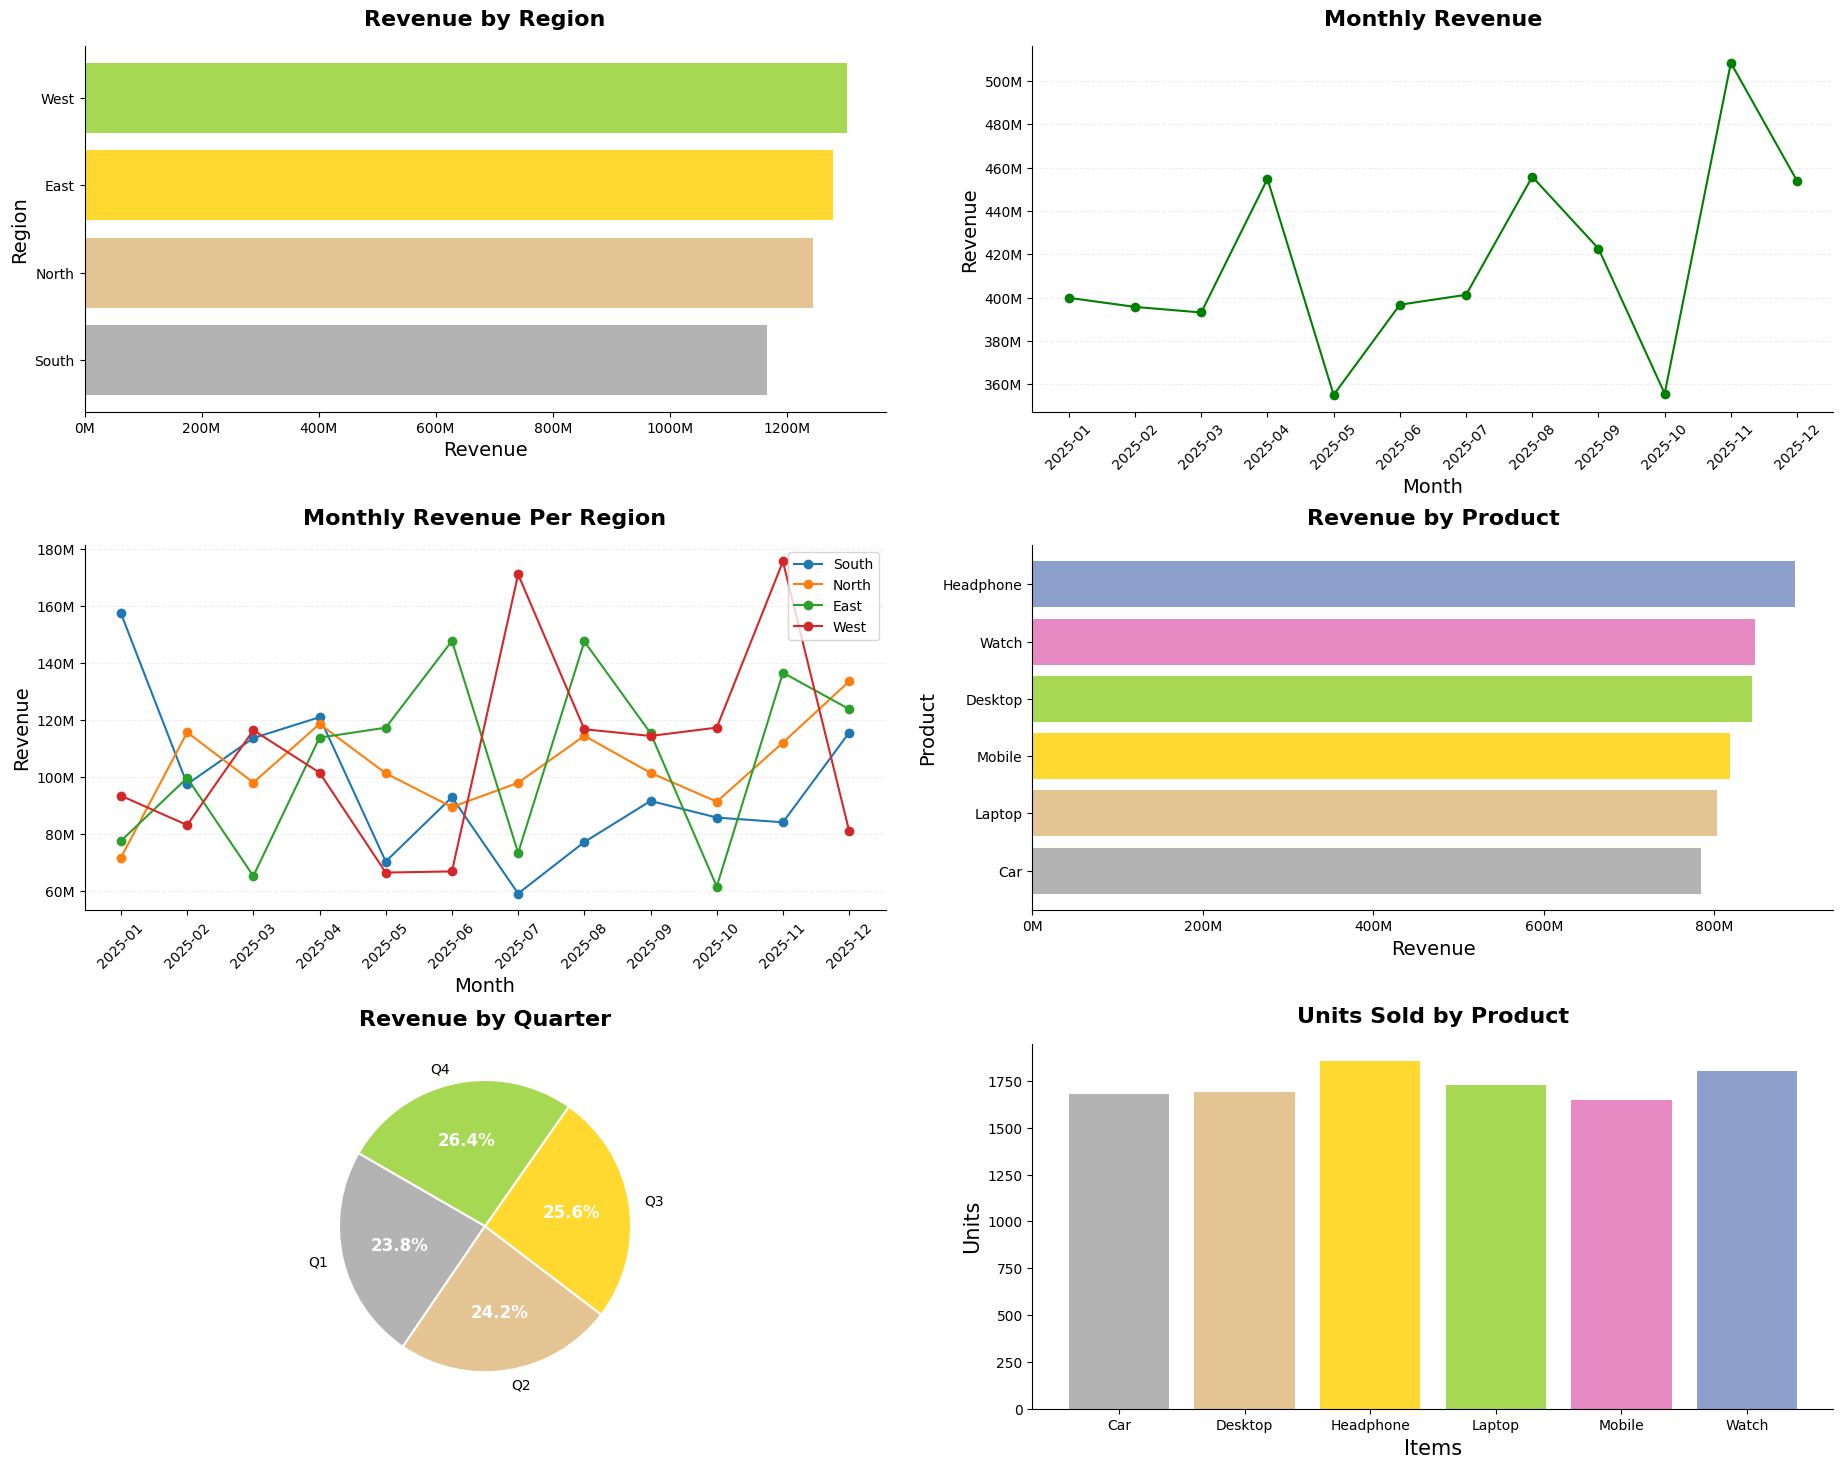

In [184]:
fig, axes = plt.subplots(3, 2, figsize=(20, 16))
plt.tight_layout(pad=7.5)

# Split axes
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]
ax5 = axes[2, 0]
ax6 = axes[2, 1]


# Plot 1: Horizontal bar chart  one bar per region, sorted by revenue
colors = plt.cm.Set2_r.colors
ax1.barh(revenue_per_region.index, revenue_per_region.values, color=colors[: len(revenue_per_region)])
ax1.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_ : f"{x/1e6:.0f}M")
)
# Add styles and texts
ax1.set_title("Revenue by Region", fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel("Revenue", fontsize=14)
ax1.set_ylabel("Region", fontsize=14)
ax1.spines[["top", "right"]].set_visible(False)



# Plot 2: Line chart (Monthly revenue) 
ax2.plot(monthly_revenue.index.astype(str), monthly_revenue.values, color='g', marker='o')
# add styles and texts
ax2.set_title("Monthly Revenue", fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel("Month", fontsize=14)
ax2.set_ylabel("Revenue", fontsize=14)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_ : f"{x/1e6:.0f}M")
)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.2)
ax2.spines[["top", "right"]].set_visible(False)



# Plot 3: Line chart (Monthly revenue of each region)
regions = revenue_per_region.index
for region in regions:
    region_df = monthly_revenue_per_region[monthly_revenue_per_region['Region'] == region]
    ax3.plot(region_df['Month'].astype(str), region_df['Revenue'], marker="o", label=region)

# add styles and texts
ax3.set_title("Monthly Revenue Per Region", fontsize=16, fontweight='bold', pad=15)
ax3.set_xlabel("Month", fontsize=14)
ax3.set_ylabel("Revenue", fontsize=14)
ax3.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_ : f"{x/1e6:.0f}M")
)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', linestyle='--', alpha=0.2)
ax3.spines[["top", "right"]].set_visible(False)
ax3.legend()



# Plot 4: Bar chart (revenue by product)
ax4.barh(revenue_per_product.index, revenue_per_product.values, color=colors[: len(revenue_per_product)])
# Add styles and texts
ax4.set_title("Revenue by Product", fontsize=16, fontweight='bold', pad=15)
ax4.set_xlabel("Revenue", fontsize=14)
ax4.set_ylabel("Product", fontsize=14)
ax4.spines[["top", "right"]].set_visible(False)
ax4.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_ : f"{x/1e6:.0f}M")
)



# Plot 5: Pie chart (Revenue by Quarter)
labels = ["Q1", "Q2", "Q3", "Q4"]
weights, texts, autotexts = ax5.pie(
    revenue_per_quarter.values,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors[: len(labels)],
    pctdistance=0.60,
    startangle=150,
    wedgeprops={"linewidth": 1.5, "edgecolor": "white"}
)

for text in autotexts:
    text.set_fontsize(12)
    text.set_color('white')
    text.set_fontweight('bold')

ax5.set_title("Revenue by Quarter", fontsize=16, fontweight='bold', pad=13)



# Plot 6: Bar chart (Units sold by product)
ax6.bar(units_sold_product.index, units_sold_product.values, color=colors[: len(units_sold_product)])
ax6.set_title("Units Sold by Product", fontsize=16, fontweight='bold', pad=15)
ax6.set_xlabel("Items", fontsize=15)
ax6.set_ylabel("Units", fontsize=15)
ax6.spines[["top", "right"]].set_visible(False)


# save the report
FILE_NAME = "sales_report.png"
plt.savefig(FILE_NAME, dpi=150, bbox_inches='tight')

plt.show()